In [2]:
import pandas as pd

In [4]:
#Simple Linear Regression


In [5]:
import pandas as pd
import numpy as np

data_simple = {
    'Years_Experience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0],
    'Salary': [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189, 63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940]
}
df_simple = pd.DataFrame(data_simple)
df_simple.head()

,Years_Experience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [7]:
#Splitting into Features (X) and Target (Y)
X_simple = df_simple[['Years_Experience']]
Y_simple = df_simple['Salary']

In [8]:
#Training the Simple Model
from sklearn.linear_model import LinearRegression

model_simple = LinearRegression()
model_simple.fit(X_simple, Y_simple)

print("Simple Linear Regression trained!")
print(f"Intercept (b0): {model_simple.intercept_:.2f}")
print(f"Coefficient/Slope (b1): {model_simple.coef_[0]:.2f}")

Simple Linear Regression trained!
Intercept (b0): 26577.40
Coefficient/Slope (b1): 9116.11


In [9]:
import pandas as pd
import numpy as np

np.random.seed(42)
years_exp = np.random.uniform(1, 15, 100)
salary = 30000 + (8500 * years_exp) + np.random.normal(0, 12000, 100)

df_advanced = pd.DataFrame({
    'Years_Experience': years_exp,
    'Salary': salary
})
df_advanced.head()

,Years_Experience,Salary
0,6.243562,84114.838962
1,14.310000,148046.914257
2,11.247915,126708.408394
3,9.381219,85889.532644
4,3.184261,54430.155559


In [10]:
# Data Splitting & Feature Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_advanced[['Years_Experience']]
Y = df_advanced['Salary']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]} samples")
print(f"Testing set size: {X_test_scaled.shape[0]} samples")

Training set size: 80 samples
Testing set size: 20 samples


In [11]:
#train and Evaluate with Advanced Cross-Validation
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

adv_model = LinearRegression()

cv_scores = cross_val_score(adv_model, X_train_scaled, Y_train, cv=5, scoring='r2')
print(f"5-Fold R2 Scores: {cv_scores}")
print(f"Mean CV R2 Stability: {cv_scores.mean():.4f}\n")

adv_model.fit(X_train_scaled, Y_train)
Y_pred = adv_model.predict(X_test_scaled)

print("--- Test Set Metrics ---")
print(f"MAE (Avg Absolute Error): ${mean_absolute_error(Y_test, Y_pred):.2f}")
print(f"RMSE (Root Mean Squared Error): ${np.sqrt(mean_squared_error(Y_test, Y_pred)):.2f}")
print(f"Final Test R2 Score: {r2_score(Y_test, Y_pred):.4f}")

5-Fold R2 Scores: [0.95072337 0.78455891 0.9065745  0.82292147 0.91157724]
Mean CV R2 Stability: 0.8753

--- Test Set Metrics ---
MAE (Avg Absolute Error): $7096.11
RMSE (Root Mean Squared Error): $9702.20
Final Test R2 Score: 0.9275


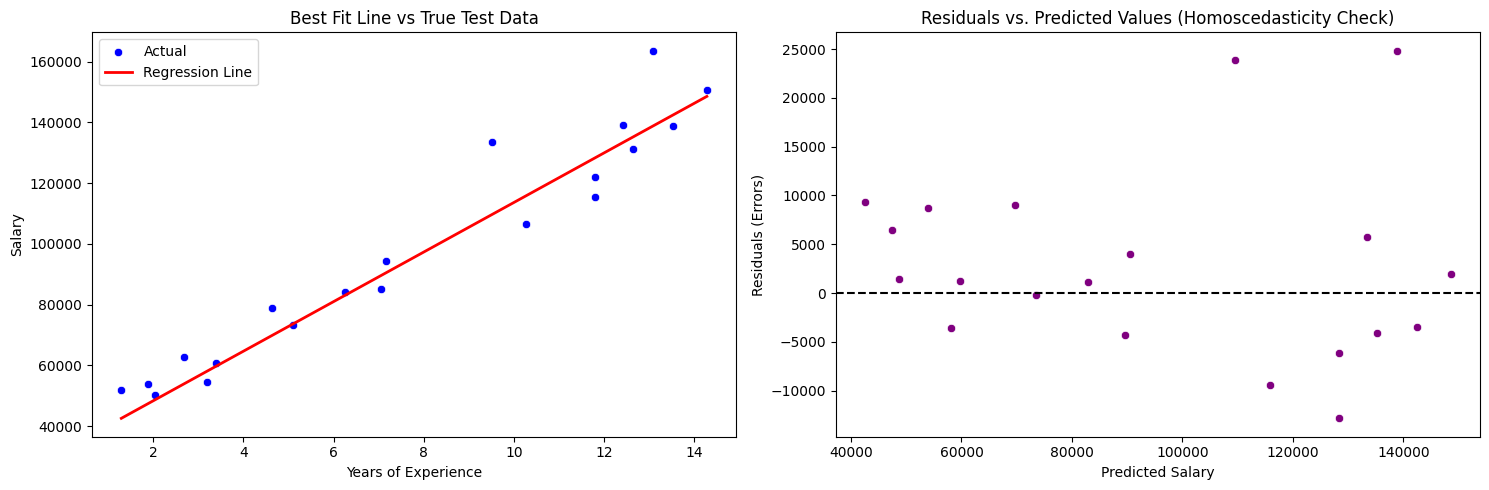

In [12]:
# Assumptions Check — Residual Analysis Plot
import matplotlib.pyplot as plt
import seaborn as sns

residuals = Y_test - Y_pred

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(x=X_test['Years_Experience'], y=Y_test, ax=ax[0], color='blue', label='Actual')
sort_idx = X_test['Years_Experience'].argsort()
ax[0].plot(X_test['Years_Experience'].iloc[sort_idx], Y_pred[sort_idx], color='red', lw=2, label='Regression Line')
ax[0].set_title("Best Fit Line vs True Test Data")
ax[0].set_xlabel("Years of Experience")
ax[0].set_ylabel("Salary")
ax[0].legend()

sns.scatterplot(x=Y_pred, y=residuals, ax=ax[1], color='purple')
ax[1].axhline(y=0, color='black', linestyle='--')
ax[1].set_title("Residuals vs. Predicted Values (Homoscedasticity Check)")
ax[1].set_xlabel("Predicted Salary")
ax[1].set_ylabel("Residuals (Errors)")

plt.tight_layout()
plt.show()

In [18]:
#Multi Linear Regression

In [19]:
import pandas as pd
import numpy as np

np.random.seed(42)
num_houses = 150

sq_ft = np.random.normal(2000, 500, num_houses)         
num_bedrooms = np.random.randint(2, 6, num_houses)     
house_age = np.random.uniform(1, 40, num_houses)       

house_price = 50000 + (120 * sq_ft) + (25000 * num_bedrooms) - (1500 * house_age) + np.random.normal(0, 15000, num_houses)

df_housing = pd.DataFrame({
    'Square_Footage': sq_ft,
    'Bedrooms': num_bedrooms,
    'House_Age': house_age,
    'Price': house_price
})
df_housing.head()

,Square_Footage,Bedrooms,House_Age,Price
0,2248.357077,5,36.616382,379391.078185
1,1930.867849,3,20.942354,325158.355903
2,2323.844269,5,20.559135,391672.342817
3,2761.514928,2,32.133512,409737.996163
4,1882.923313,5,26.348593,356791.519928


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_multi = df_housing[['Square_Footage', 'Bedrooms', 'House_Age']]
Y_multi = df_housing['Price']

X_train, X_test, Y_train, Y_test = train_test_split(X_multi, Y_multi, test_size=0.2, random_state=42)

scaler_multi = StandardScaler()
X_train_scaled = scaler_multi.fit_transform(X_train)
X_test_scaled = scaler_multi.transform(X_test)

In [22]:
from sklearn.linear_model import LinearRegression

model_multi = LinearRegression()
model_multi.fit(X_train_scaled, Y_train)

print(f"Model training complete.")
print(f"Base intercept (b0): ${model_multi.intercept_:.2f}")

Model training complete.
Base intercept (b0): $342337.07


In [23]:
coefficients_df = pd.DataFrame({
    'Feature': X_multi.columns,
    'Weight/Coefficient': model_multi.coef_
})

coefficients_df['Abs_Impact'] = coefficients_df['Weight/Coefficient'].abs()
coefficients_df = coefficients_df.sort_values(by='Abs_Impact', ascending=False).drop(columns=['Abs_Impact'])

print("--- Evaluated Feature Impacts on House Price ---")
print(coefficients_df.to_string(index=False))

--- Evaluated Feature Impacts on House Price ---
       Feature  Weight/Coefficient
Square_Footage        56975.510010
      Bedrooms        28483.355297
     House_Age       -16526.602682


In [25]:
coefficients_df = pd.DataFrame({
    'Feature': X_multi.columns,
    'Weight/Coefficient': model_multi.coef_
})

coefficients_df['Abs_Impact'] = coefficients_df['Weight/Coefficient'].abs()
coefficients_df = coefficients_df.sort_values(by='Abs_Impact', ascending=False).drop(columns=['Abs_Impact'])

print("Evaluated Feature Impacts on House Price")
print(coefficients_df.to_string(index=False))

Evaluated Feature Impacts on House Price
       Feature  Weight/Coefficient
Square_Footage        56975.510010
      Bedrooms        28483.355297
     House_Age       -16526.602682
